Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (200, 5)

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Dataset Preview:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Summary Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


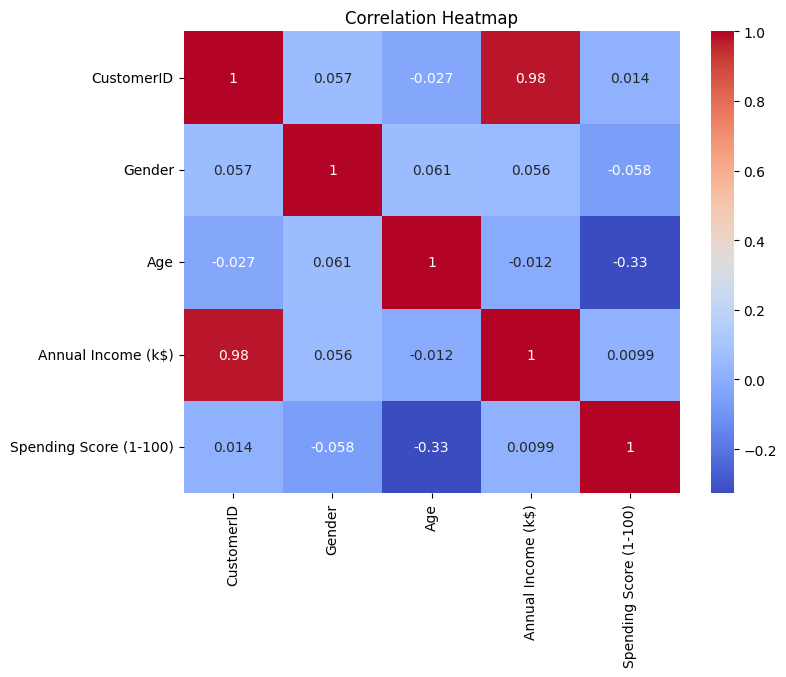

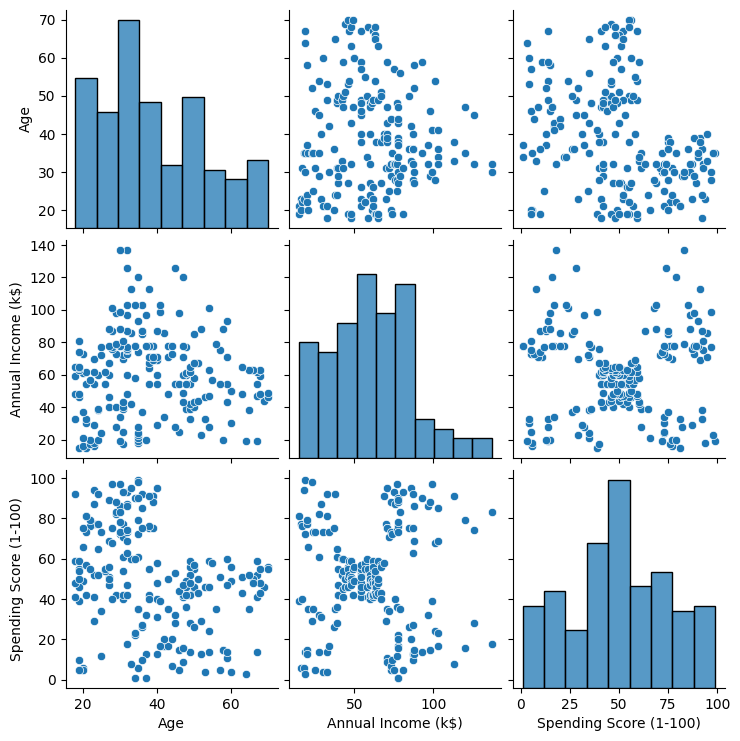

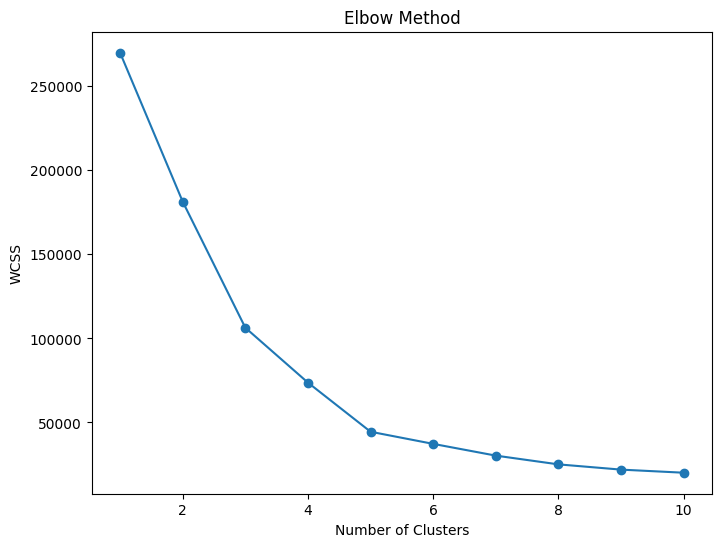

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


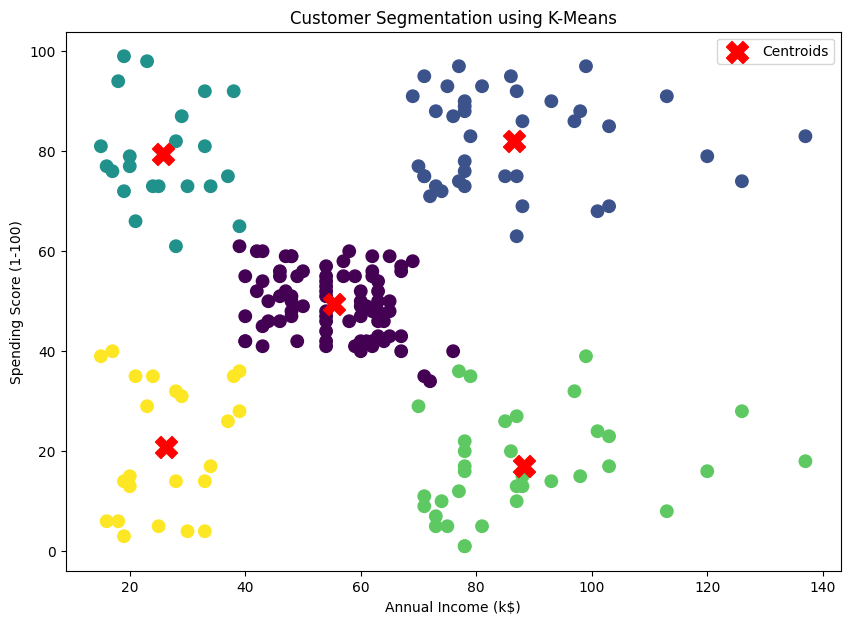


Customers in each cluster:

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

Cluster Centers:



,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043



Model saved as kmeans_model.pkl
Enter Annual Income (k$): 746464
Enter Spending Score (1-100): 67

Predicted Cluster: 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [2]:
# ================================
# SkillCraft Technology
# Data Science Internship - Task 02
# Customer Segmentation using K-Means Clustering
# ================================

from google.colab import drive
drive.mount('/content/drive')

# ================================
# Import Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# ================================
# Load Dataset
# ================================

df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Preview:")
display(df.head())

print("\nSummary Statistics:")
display(df.describe())

# ================================
# Encode Gender
# ================================

encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])

# ================================
# Correlation Heatmap
# ================================

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ================================
# Pairplot
# ================================

sns.pairplot(df[['Age',
                 'Annual Income (k$)',
                 'Spending Score (1-100)']])

plt.show()

# ================================
# Select Features
# ================================

X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

# ================================
# Elbow Method
# ================================

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# ================================
# Train KMeans
# ================================

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

print(df.head())

# ================================
# Cluster Visualization
# ================================

plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=df['Cluster'],
    cmap='viridis',
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='red',
    s=250,
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.legend()

plt.show()

# ================================
# Cluster Counts
# ================================

print("\nCustomers in each cluster:\n")

print(df['Cluster'].value_counts())

# ================================
# Cluster Centers
# ================================

centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)',
             'Spending Score (1-100)']
)

print("\nCluster Centers:\n")

display(centers)

# ================================
# Save Model
# ================================

with open('kmeans_model.pkl','wb') as file:
    pickle.dump(kmeans,file)

print("\nModel saved as kmeans_model.pkl")

# ================================
# Load Model
# ================================

with open('kmeans_model.pkl','rb') as file:
    loaded_model = pickle.load(file)

# ================================
# Predict New Customer
# ================================

income = float(input("Enter Annual Income (k$): "))
score = float(input("Enter Spending Score (1-100): "))

new_customer = [[income,score]]

cluster = loaded_model.predict(new_customer)

print("\nPredicted Cluster:", cluster[0])